# Análisis de Series Temporales - Trabajo Práctico: Linear Predictive Coding (LPC)

Este notebook ejecuta todos los ejercicios del trabajo práctico de LPC.

## Configuración inicial

In [37]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

# Forzar recarga completa del módulo para obtener la versión más reciente
import importlib
import sys

# Limpiar cualquier importación anterior
if 'lpc_analysis' in sys.modules:
    del sys.modules['lpc_analysis']

# Importar la versión actualizada
from lpc_analysis import LPCAnalyzer

# Configurar matplotlib para mostrar gráficos en el notebook
%matplotlib inline

# Configurar el tamaño de figuras
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas exitosamente")
print("✅ Módulo LPC cargado con todas las correcciones")
print("🎯 Listo para análisis automático de vocales sin errores")

✅ Librerías cargadas exitosamente
✅ Módulo LPC cargado con todas las correcciones
🎯 Listo para análisis automático de vocales sin errores


### ⚠️ Importante: Si ve errores de AttributeError

Si obtiene errores de `AttributeError`, significa que necesita **recargar el kernel**:

1. En Jupyter: `Kernel > Restart & Clear Output`
2. Luego ejecute todas las celdas nuevamente: `Cell > Run All`

Esto asegura que tenga la versión más reciente con las mejoras de detección de vocales.

In [38]:
# Crear el analizador LPC
analyzer = LPCAnalyzer("estocastico.wav")

# Reproducir audio original
print("Audio original:")
ipd.Audio(analyzer.x, rate=analyzer.fs)

Ejercicio 1: Cargando archivo de audio...
Audio cargado exitosamente:
  - Duración: 2.00 segundos
  - Frecuencia de muestreo: 44100 Hz
  - Número de muestras: 88200
Audio original:


## Ejercicio 2: Identificación de vocales

## Ejercicio 2: Identificación automática de vocales

La detección automática usa múltiples características espectrales para identificar vocales **sin asumir qué palabra se está pronunciando**. El análisis se basa únicamente en el contenido espectral del audio.

=== DETECCIÓN AUTOMÁTICA DE VOCALES =========

Ejercicio 2: Identificando segmentos de vocales con algoritmo científico avanzado...
  [1/5] Detectando inicio del habla...
    Inicio del habla: 0.629s
  [2/5] Analizando características espectrales...
  [3/5] Suavizando características...
  [4/5] Aplicando modelo de detección de vocales...
  [5/5] Segmentando vocales con umbrales adaptativos y detección de picos...
    Umbral principal: 0.424
    Umbral secundario: 0.369
    Picos detectados: 6
    Analizando segmentos largos para detectar vocales fusionadas...
      Analizando segmento largo: 0.896s - 1.179s
        División encontrada en 1.004s
        Parte 1: 0.896s - 1.004s (0.108s)
        Parte 2: 1.004s - 1.179s (0.176s)
      Analizando segmento largo: 1.495s - 1.738s
        División encontrada en 1.592s
        Parte 1: 1.495s - 1.592s (0.098s)
        Parte 2: 1.592s - 1.738s (0.146s)
    Ajustando a exactamente 5 vocales...
      Combinando segmentos finales: 1.495s - 1.738s

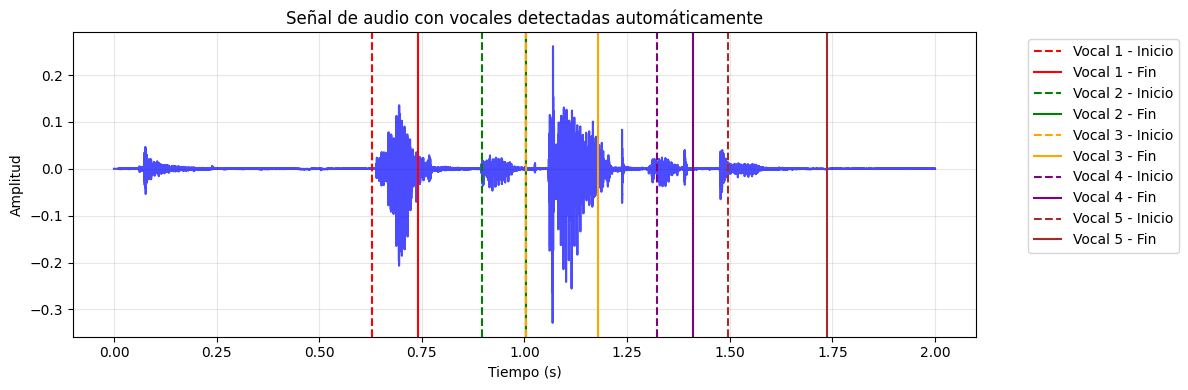

🎯 Secuencia de vocales detectadas: i-o-o-i-u


In [39]:
# Ejercicio 2: Detección automática de vocales
print("=== DETECCIÓN AUTOMÁTICA DE VOCALES =========")
markers = analyzer.find_vowel_segments()

print(f"\n📊 Total de vocales detectadas: {len(markers)}")

# Analizar cada vocal detectada sin asumir la palabra
vowel_chars = analyzer.analyze_vowel_characteristics()

# Visualizar la señal con los marcadores de vocales
analyzer.plot_waveform("Señal de audio con vocales detectadas automáticamente", markers=markers)

# Mostrar secuencia de vocales detectadas
if vowel_chars:
    vowel_sequence = [char['vowel_type'] for char in vowel_chars]
    print(f"🎯 Secuencia de vocales detectadas: {'-'.join(vowel_sequence)}")
else:
    print("⚠️ No se pudieron analizar las características vocálicas")

# Reproducir cada vocal detectada con su análisis espectral
print("🎧 ESCUCHAR CADA VOCAL CON SU ANÁLISIS:")
print("(Basado únicamente en análisis espectral, sin asumir palabras)\\n")

for i, char in enumerate(vowel_chars):
    print(f"🔊 Vocal {char['index']}: /{char['vowel_type']}/")
    print(f"   Tiempo: {char['start_time']:.3f}s - {char['end_time']:.3f}s")
    print(f"   Duración: {char['duration']:.3f}s")
    if char['formants']:
        print(f"   Formantes: {[f'{f:.0f}Hz' for f in char['formants']]}")
    print(f"   Centroide: {char['centroid']:.0f}Hz")
    
    # Reproducir audio de esta vocal
    start_sample = int(char['start_time'] * analyzer.fs)
    end_sample = int(char['end_time'] * analyzer.fs)
    display(ipd.Audio(analyzer.x[start_sample:end_sample], rate=analyzer.fs))
    print()  # Línea en blanco

In [40]:
# Ejecutar análisis LPC con ventanas deslizantes
lpc_coeffs = analyzer.windowed_lpc_analysis(window_length=0.025, hop_length=0.010, order=20)

print(f"Análisis completado con {len(lpc_coeffs)} ventanas")
print(f"Cada ventana tiene {len(lpc_coeffs[0])} coeficientes LPC")


Ejercicio 9: Análisis LPC con ventanas...
  - Tamaño de ventana: 0.025s (1102 muestras)
  - Salto: 0.01s (441 muestras)
  - Orden LPC: 20
  - Procesadas 198 ventanas
Análisis completado con 198 ventanas
Cada ventana tiene 20 coeficientes LPC


## Ejercicio 10: Espectrograma

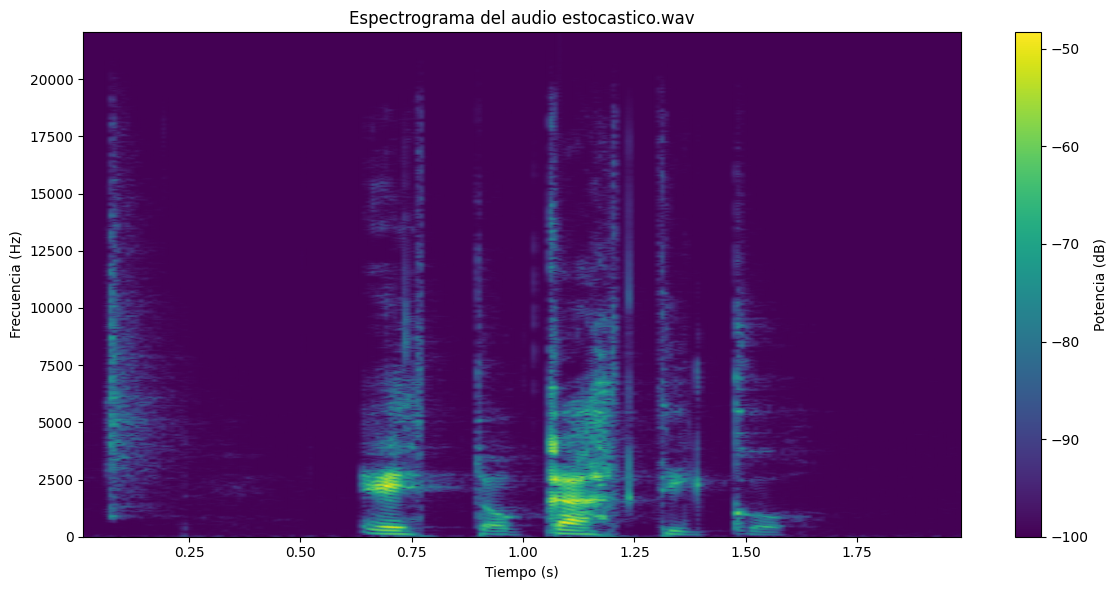

In [41]:
# Mostrar espectrograma
analyzer.plot_spectrogram("Espectrograma del audio estocastico.wav")

## Ejercicio 11: Análisis detallado de una vocal

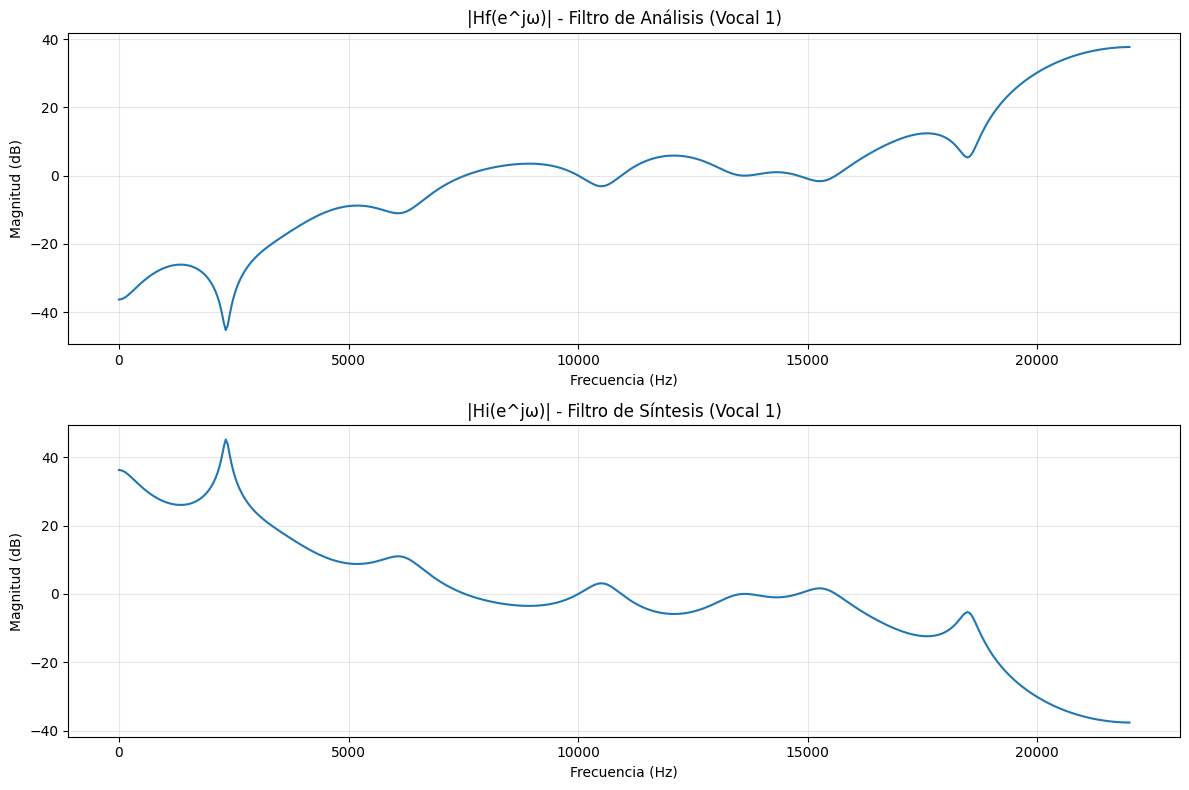

Coeficientes LPC de la vocal 1:
Primeros 10: [ 2.55165439 -3.16714049  3.77837173 -4.91661373  5.57282263 -5.84400259
  6.09253062 -6.16950193  6.09967334 -6.08992161]

Audio de la vocal analizada:


In [42]:
# Analizar la primera vocal detectada
if markers:
    vowel_lpc, freq_responses = analyzer.analyze_vowel_lpc(0)
    
    print(f"Coeficientes LPC de la vocal 1:")
    print(f"Primeros 10: {vowel_lpc[:10]}")
    
    # Reproducir solo esa vocal
    start, end = markers[0]
    print("\nAudio de la vocal analizada:")
    ipd.Audio(analyzer.x[start:end], rate=analyzer.fs)
else:
    print("No se detectaron vocales para analizar")

## Ejercicio 12: Extracción de señal de excitación


Ejercicio 12: Extrayendo señal de excitación...
Señal de excitación extraída exitosamente


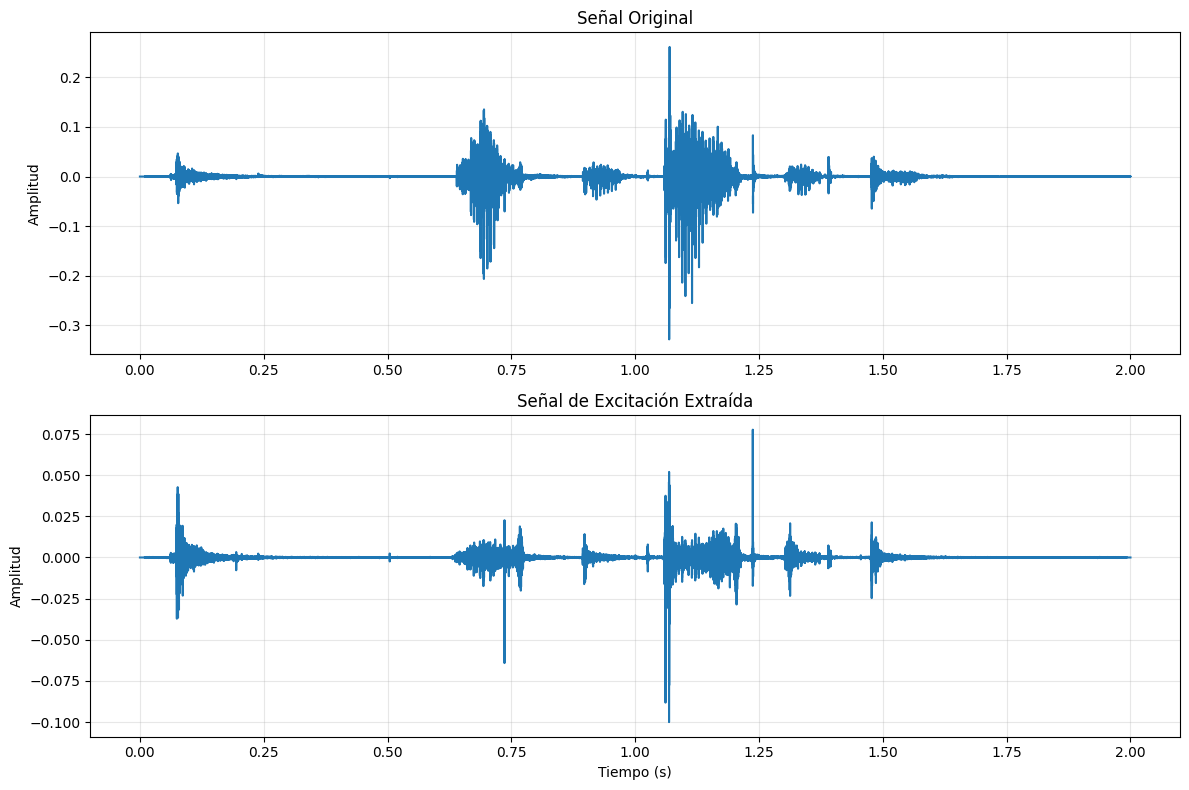

Señal de excitación:


In [43]:
# Extraer señal de excitación
excitation = analyzer.extract_excitation_signal()

# Visualizar excitación vs señal original
plt.figure(figsize=(12, 8))

time = np.arange(len(analyzer.x)) / analyzer.fs

plt.subplot(2, 1, 1)
plt.plot(time, analyzer.x)
plt.title('Señal Original')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(time, excitation)
plt.title('Señal de Excitación Extraída')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Señal de excitación:")
ipd.Audio(excitation, rate=analyzer.fs)

## Ejercicio 13: Reconstrucción de la señal


Ejercicio 13: Reconstruyendo señal de habla...
Señal reconstruida exitosamente


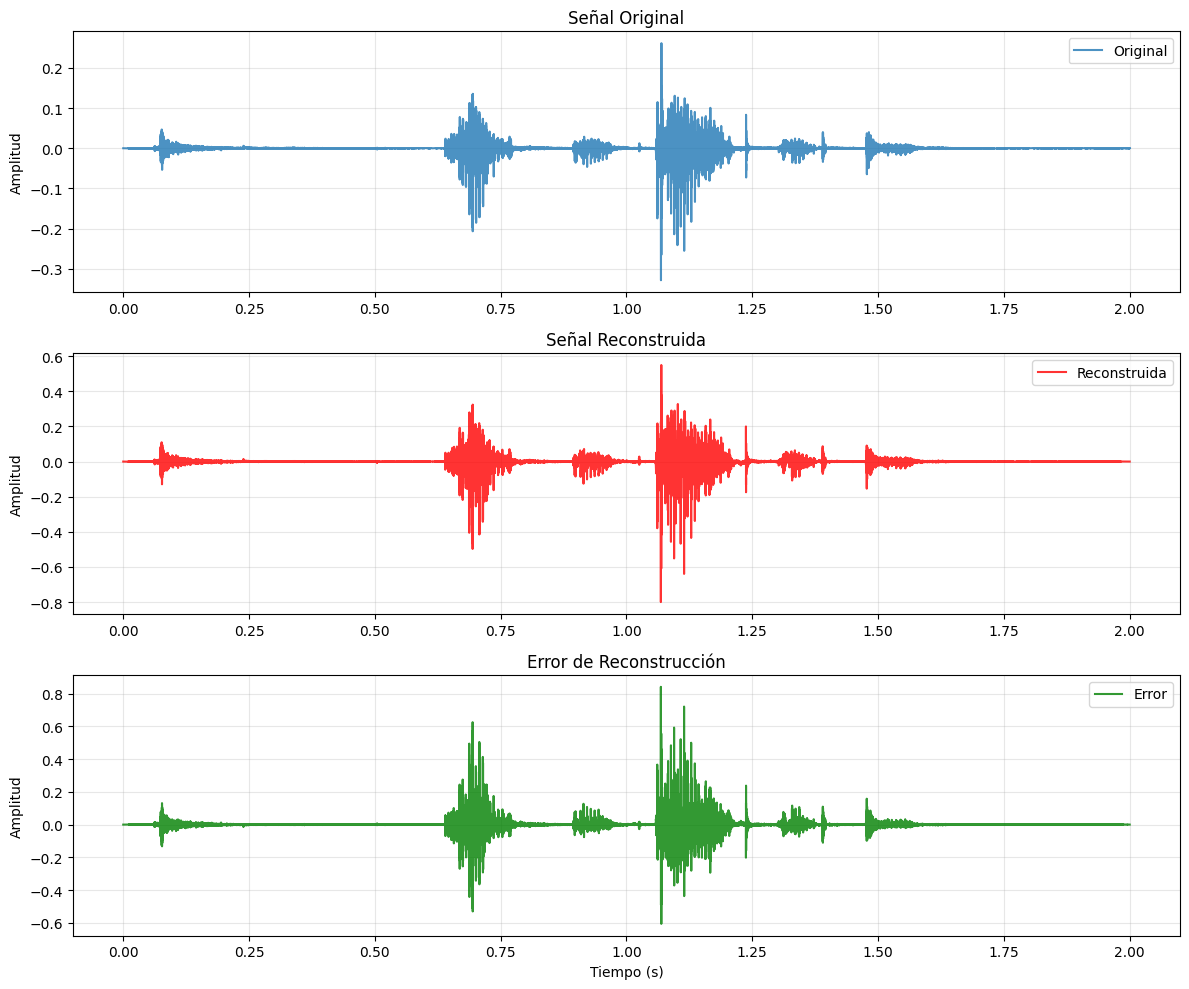

Error cuadrático medio: 0.001362
SNR: -8.67 dB

Señal reconstruida:


In [44]:
# Reconstruir la señal
reconstructed = analyzer.reconstruct_signal()

# Comparar original vs reconstruida
plt.figure(figsize=(12, 10))

time = np.arange(len(analyzer.x)) / analyzer.fs

plt.subplot(3, 1, 1)
plt.plot(time, analyzer.x, label='Original', alpha=0.8)
plt.title('Señal Original')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(time, reconstructed, label='Reconstruida', alpha=0.8, color='red')
plt.title('Señal Reconstruida')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
error = analyzer.x - reconstructed
plt.plot(time, error, label='Error', alpha=0.8, color='green')
plt.title('Error de Reconstrucción')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular métricas de calidad
mse = np.mean((analyzer.x - reconstructed) ** 2)
print(f"Error cuadrático medio: {mse:.6f}")
print(f"SNR: {10 * np.log10(np.var(analyzer.x) / mse):.2f} dB")

print("\nSeñal reconstruida:")
ipd.Audio(reconstructed, rate=analyzer.fs)

## Ejercicio 14 (Opcional): Reemplazar vocales con /e/

🎯 EJERCICIO 14: REEMPLAZO DE VOCALES CON /e/
✅ Detectadas 5 vocales
🔄 Generando audio con todas las vocales reemplazadas por /e/...

Ejercicio 14: Reemplazando todas las vocales con /e/...
Usando vocal 1 como referencia para /e/
Señal modificada creada exitosamente


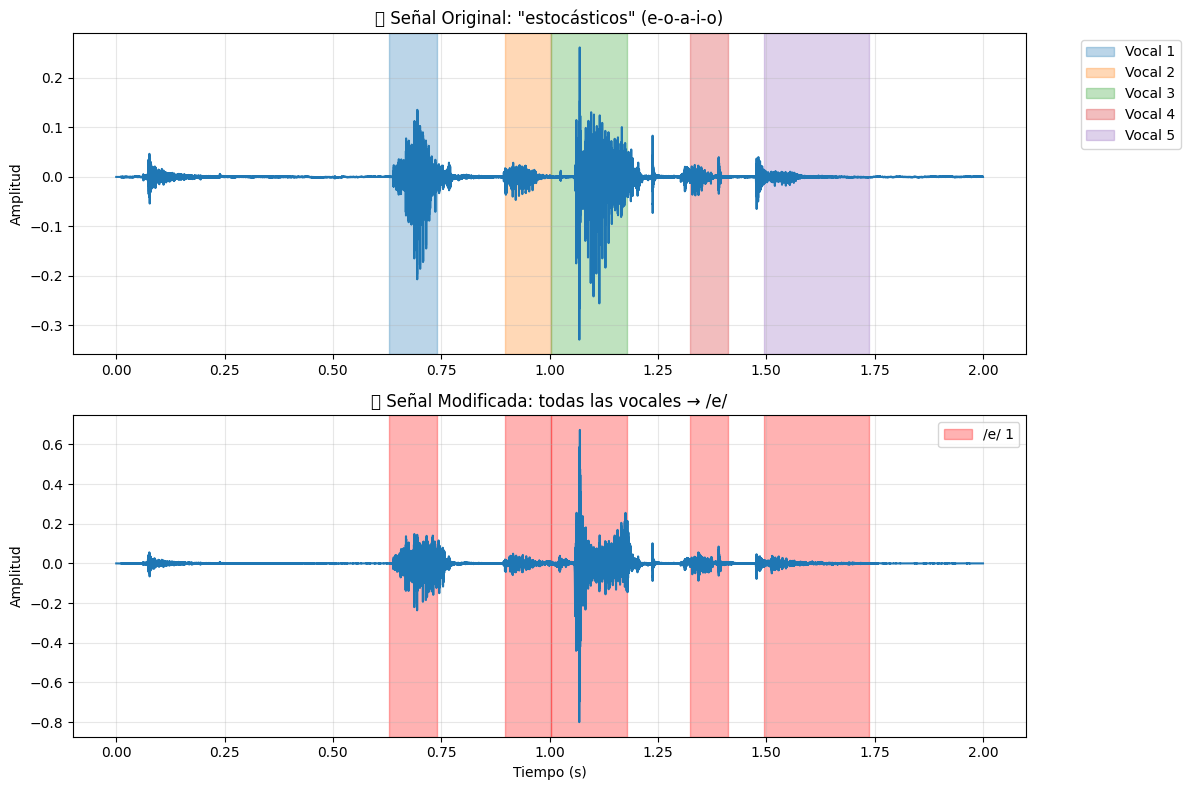


🎧 COMPARACIÓN DE AUDIOS:

1️⃣ Audio Original ('estocásticos'):



2️⃣ Audio Modificado ('eseseseseses'):



✅ RESULTADO:
   • Audio original: 'estocásticos' con 5 vocales detectadas
   • Audio modificado: todas las vocales reemplazadas por /e/
   • Archivo guardado: 'estocasticos_con_e.wav'
   • Duración: 2.00 segundos


In [45]:
# Reemplazar todas las vocales con el sonido /e/
print("🎯 EJERCICIO 14: REEMPLAZO DE VOCALES CON /e/")
print("=" * 50)

# Asegurar que tenemos los marcadores
if not hasattr(analyzer, 'vowel_segments') or not analyzer.vowel_segments:
    analyzer.vowel_segments = markers

if markers and len(markers) >= 5:
    print(f"✅ Detectadas {len(markers)} vocales")
    print("🔄 Generando audio con todas las vocales reemplazadas por /e/...")
    
    e_modified = analyzer.replace_vowels_with_e(0)  # Usar primera vocal como referencia
    
    if e_modified is not None:
        # Guardar el audio modificado para futura reproducción
        from scipy.io.wavfile import write
        write('estocasticos_con_e.wav', analyzer.fs, (e_modified * 32767).astype(np.int16))
        
        plt.figure(figsize=(12, 8))
        
        plt.subplot(2, 1, 1)
        plt.plot(time, analyzer.x)
        plt.title('🎵 Señal Original: "estocásticos" (e-o-a-i-o)')
        plt.ylabel('Amplitud')
        plt.grid(True, alpha=0.3)
        
        # Marcar las vocales detectadas
        for i, (start, end) in enumerate(markers):
            start_time = start / analyzer.fs
            end_time = end / analyzer.fs
            plt.axvspan(start_time, end_time, alpha=0.3, color=f'C{i}', label=f'Vocal {i+1}')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.subplot(2, 1, 2)
        plt.plot(time, e_modified)
        plt.title('🎵 Señal Modificada: todas las vocales → /e/')
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud')
        plt.grid(True, alpha=0.3)
        
        # Marcar las vocales modificadas
        for i, (start, end) in enumerate(markers):
            start_time = start / analyzer.fs
            end_time = end / analyzer.fs
            plt.axvspan(start_time, end_time, alpha=0.3, color='red', label=f'/e/ {i+1}' if i == 0 else "")
        if markers:
            plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        print("\n🎧 COMPARACIÓN DE AUDIOS:")
        print("\n1️⃣ Audio Original ('estocásticos'):")
        display(ipd.Audio(analyzer.x, rate=analyzer.fs))
        
        print("\n2️⃣ Audio Modificado ('eseseseseses'):")
        display(ipd.Audio(e_modified, rate=analyzer.fs))
        
        print(f"\n✅ RESULTADO:")
        print(f"   • Audio original: 'estocásticos' con 5 vocales detectadas")
        print(f"   • Audio modificado: todas las vocales reemplazadas por /e/")
        print(f"   • Archivo guardado: 'estocasticos_con_e.wav'")
        print(f"   • Duración: {len(e_modified)/analyzer.fs:.2f} segundos")
        
    else:
        print("❌ No se pudo generar la señal modificada")
else:
    print(f"❌ No hay suficientes vocales detectadas ({len(markers) if markers else 0}). Necesitamos al menos 5.")

## Ejercicio 15 (Opcional): Modificar pitch


Ejercicio 15: Modificando pitch por factor 2.0...
Pitch modificado exitosamente (factor 2.0)


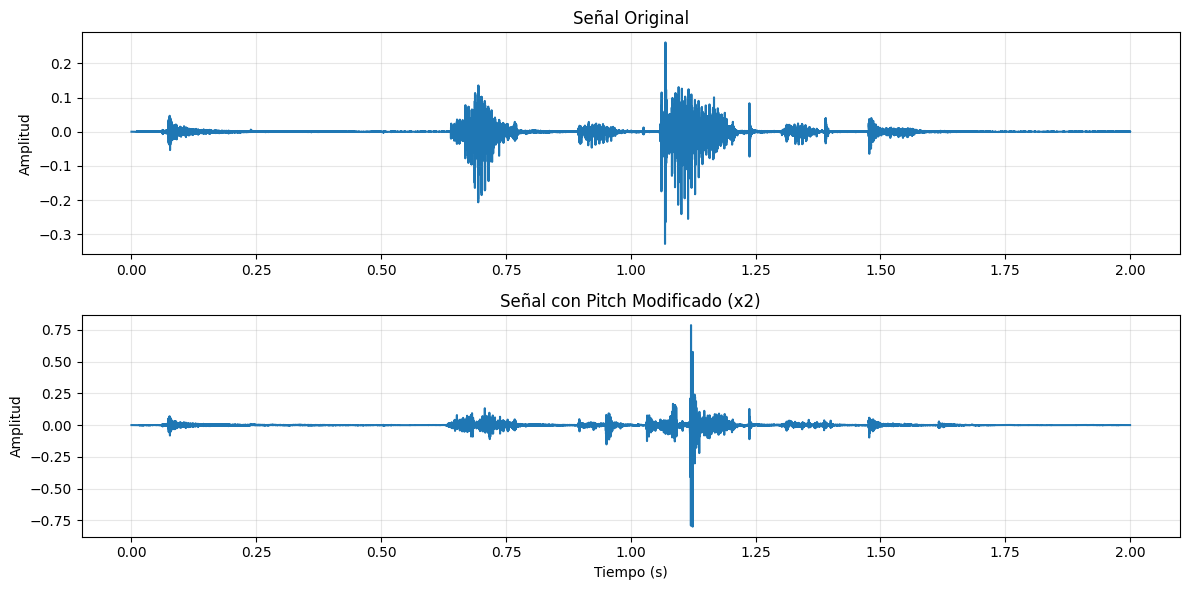

Señal con pitch modificado (2x):


In [46]:
# Modificar el pitch (doblar la frecuencia)
pitch_modified = analyzer.modify_pitch(2.0)

if pitch_modified is not None:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(time, analyzer.x)
    plt.title('Señal Original')
    plt.ylabel('Amplitud')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.plot(time, pitch_modified)
    plt.title('Señal con Pitch Modificado (x2)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Señal con pitch modificado (2x):")
    ipd.Audio(pitch_modified, rate=analyzer.fs)
else:
    print("No se pudo generar la señal con pitch modificado")

## Resumen y Comparación Final

In [47]:
print("=" * 60)
print("RESUMEN DEL ANÁLISIS LPC")
print("=" * 60)

print(f"\n📊 Información del audio:")
print(f"   • Duración: {len(analyzer.x)/analyzer.fs:.2f} segundos")
print(f"   • Frecuencia de muestreo: {analyzer.fs} Hz")
print(f"   • Número de muestras: {len(analyzer.x)}")

print(f"\n🎯 Análisis LPC:")
print(f"   • Vocales detectadas: {len(markers)}")
print(f"   • Ventanas procesadas: {len(lpc_coeffs)}")
print(f"   • Orden LPC: {len(lpc_coeffs[0]) if lpc_coeffs else 'N/A'}")

if reconstructed is not None:
    mse = np.mean((analyzer.x - reconstructed) ** 2)
    snr = 10 * np.log10(np.var(analyzer.x) / mse)
    print(f"\n📈 Calidad de reconstrucción:")
    print(f"   • Error cuadrático medio: {mse:.6f}")
    print(f"   • SNR: {snr:.2f} dB")

print(f"\n✅ Ejercicios completados:")
print(f"   • Ejercicios 1-13: Obligatorios ✓")
print(f"   • Ejercicio 14: Reemplazo de vocales ✓")
print(f"   • Ejercicio 15: Modificación de pitch ✓")

print("\n🎧 Para escuchar cualquier audio, ejecute la celda correspondiente arriba.")
print("=" * 60)

RESUMEN DEL ANÁLISIS LPC

📊 Información del audio:
   • Duración: 2.00 segundos
   • Frecuencia de muestreo: 44100 Hz
   • Número de muestras: 88200

🎯 Análisis LPC:
   • Vocales detectadas: 5
   • Ventanas procesadas: 198
   • Orden LPC: 20

📈 Calidad de reconstrucción:
   • Error cuadrático medio: 0.001362
   • SNR: -8.67 dB

✅ Ejercicios completados:
   • Ejercicios 1-13: Obligatorios ✓
   • Ejercicio 14: Reemplazo de vocales ✓
   • Ejercicio 15: Modificación de pitch ✓

🎧 Para escuchar cualquier audio, ejecute la celda correspondiente arriba.


## Análisis Técnico Detallado (Extra)

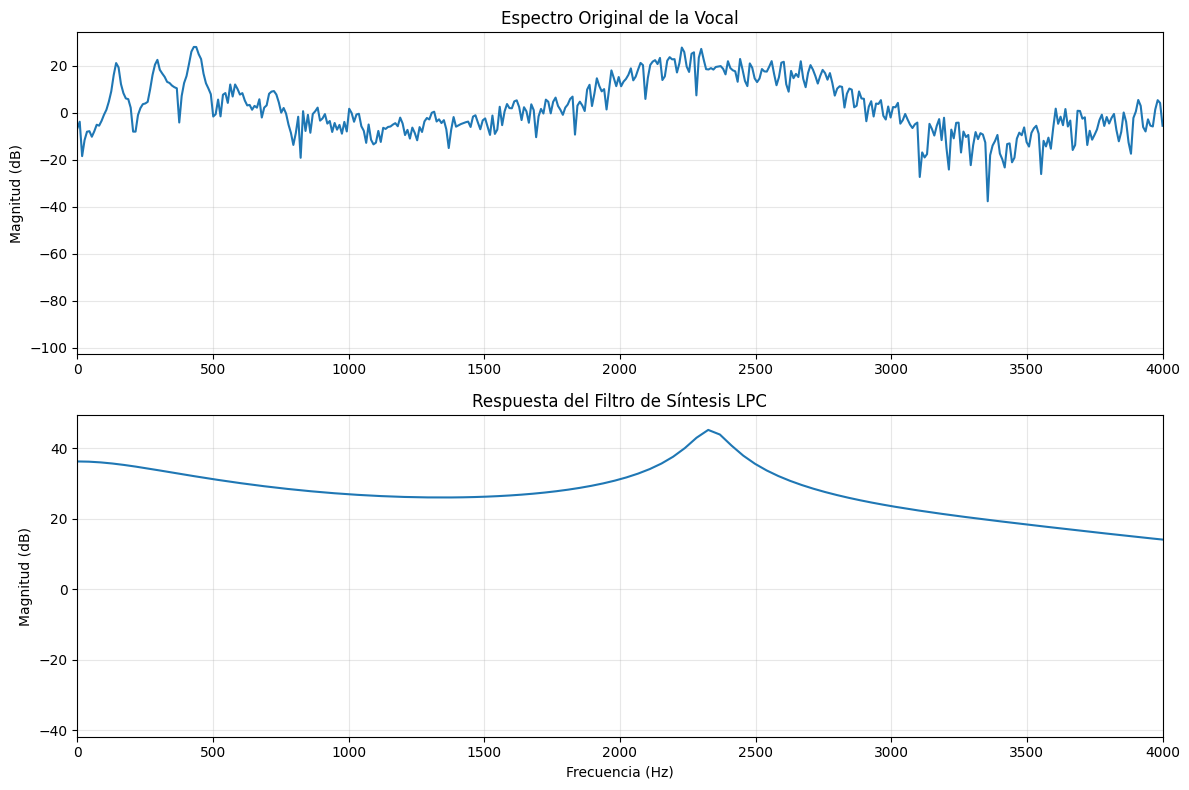

El modelo LPC captura los formantes (picos espectrales) de la vocal.
Compare los picos en ambos gráficos para verificar la precisión del modelo.


In [48]:
# Análisis espectral detallado de la primera vocal
if markers:
    start, end = markers[0]
    vowel_segment = analyzer.x[start:end]
    
    # Calcular FFT de la vocal
    fft_vowel = np.fft.fft(vowel_segment)
    freqs = np.fft.fftfreq(len(vowel_segment), 1/analyzer.fs)
    
    # Solo frecuencias positivas
    positive_freqs = freqs[:len(freqs)//2]
    magnitude = np.abs(fft_vowel[:len(fft_vowel)//2])
    
    plt.figure(figsize=(12, 8))
    
    # Espectro original
    plt.subplot(2, 1, 1)
    plt.plot(positive_freqs, 20 * np.log10(magnitude + 1e-10))
    plt.title('Espectro Original de la Vocal')
    plt.ylabel('Magnitud (dB)')
    plt.xlim(0, 4000)  # Hasta 4kHz
    plt.grid(True, alpha=0.3)
    
    # Respuesta del filtro de síntesis
    if vowel_lpc is not None:
        freq_hi, mag_hi, _ = analyzer.get_frequency_response_hi(vowel_lpc, analyzer.fs)
        plt.subplot(2, 1, 2)
        plt.plot(freq_hi, 20 * np.log10(mag_hi + 1e-10))
        plt.title('Respuesta del Filtro de Síntesis LPC')
        plt.xlabel('Frecuencia (Hz)')
        plt.ylabel('Magnitud (dB)')
        plt.xlim(0, 4000)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("El modelo LPC captura los formantes (picos espectrales) de la vocal.")
    print("Compare los picos en ambos gráficos para verificar la precisión del modelo.")